In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# configuración visual
sns.set(style="whitegrid")

# generar dataset (código base)
np.random.seed(42)
n_samples = 500

data = {
    'Metros_Cuadrados': np.random.normal(150, 50, n_samples),
    'N_Habitaciones': np.random.randint(1, 6, n_samples),
    'Antiguedad_Anos': np.random.exponential(10, n_samples),
    'Distancia_Centro_Km': np.random.uniform(1, 20, n_samples),
    'Calidad_Materiales': np.random.choice(['Baja', 'Media', 'Alta', 'Lujo'], n_samples),
    'Tiene_Garaje': np.random.choice([0, 1], n_samples)
}

df = pd.DataFrame(data)

# crear variable target (precio)
df['Precio'] = (
    df['Metros_Cuadrados'] * 1200 + 
    df['N_Habitaciones'] * 5000 - 
    df['Antiguedad_Anos'] * 800 + 
    np.random.normal(0, 5000, n_samples)
)

# variable redundante para el ejercicio 3
df['Pies_Cuadrados'] = df['Metros_Cuadrados'] * 10.76 

print("dataset cargado:", df.shape)
df.head()

dataset cargado: (500, 8)


,Metros_Cuadrados,N_Habitaciones,Antiguedad_Anos,Distancia_Centro_Km,Calidad_Materiales,Tiene_Garaje,Precio,Pies_Cuadrados
0,174.835708,2,14.621971,15.829985,Lujo,0,200067.472976,1881.232214
1,143.086785,2,5.408842,6.221315,Alta,1,173563.444488,1539.613806
2,182.384427,3,5.470696,16.629672,Media,0,225639.043931,1962.456433
3,226.151493,3,13.378178,9.051027,Alta,1,270979.733671,2433.390063
4,138.292331,5,2.728291,13.683448,Lujo,0,192915.538766,1488.025484


In [ ]:
# ejercicio 2: crear variiables
# hago esto antes del split para tener todo listo

# logaritmo para la antigüedad para evitar sesgos
df['Log_Antiguedad'] = np.log1p(df['Antiguedad_Anos'])

# variable de eficiencia (precio / metros)
df['Eficiencia_Espacio'] = df['Precio'] / df['Metros_Cuadrados']

# mapeo de calidad a numeros
mapa = {'Baja': 1, 'Media': 2, 'Alta': 3, 'Lujo': 4}
df['Calidad_Num'] = df['Calidad_Materiales'].map(mapa)

print("variables nuevas creadas")
print(df[['Antiguedad_Anos', 'Log_Antiguedad', 'Calidad_Materiales', 'Calidad_Num']].head())

variables nuevas creadas
   Antiguedad_Anos  Log_Antiguedad Calidad_Materiales  Calidad_Num
0        14.621971        2.748678               Lujo            4
1         5.408842        1.857679               Alta            3
2         5.470696        1.867284              Media            2
3        13.378178        2.665712               Alta            3
4         2.728291        1.315950               Lujo            4


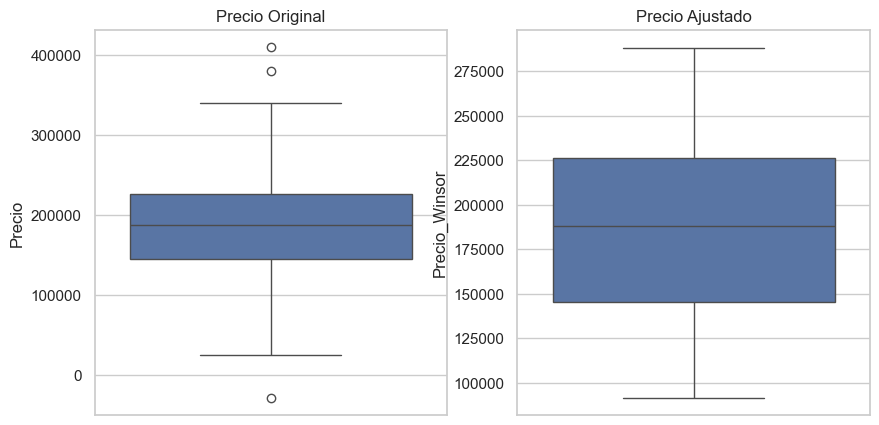

In [3]:
# ejercicio 4: outliers
plt.figure(figsize=(10, 5))

# grafico original
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Precio'])
plt.title("Precio Original")

# winsorization (limitar al 5% y 95%)
p05 = df['Precio'].quantile(0.05)
p95 = df['Precio'].quantile(0.95)

df['Precio_Winsor'] = df['Precio'].clip(lower=p05, upper=p95)

# grafico despues del winsor
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Precio_Winsor'])
plt.title("Precio Ajustado")
plt.show()

# actualizamos el dataframe
df = df.drop(columns=['Precio'])
df = df.rename(columns={'Precio_Winsor': 'Precio'})

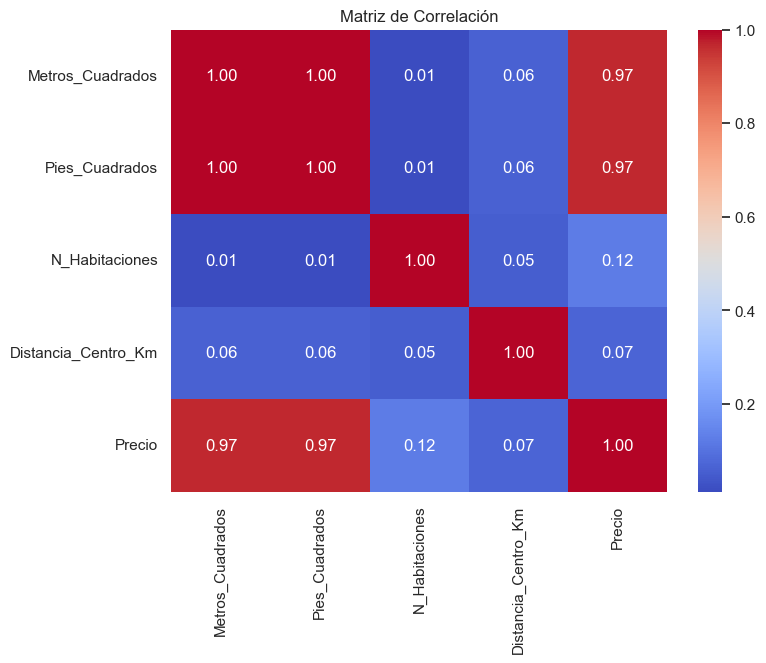

pares con mucha correlacion:
            level_0           level_1         0
1  Metros_Cuadrados    Pies_Cuadrados  1.000000
2  Metros_Cuadrados            Precio  0.967097
3    Pies_Cuadrados  Metros_Cuadrados  1.000000
5    Pies_Cuadrados            Precio  0.967097
8            Precio  Metros_Cuadrados  0.967097
9            Precio    Pies_Cuadrados  0.967097


In [8]:
# ejercicio 3: correlacionn
# selecciono solo las numericas relevantes
cols = ['Metros_Cuadrados', 'Pies_Cuadrados', 'N_Habitaciones', 'Distancia_Centro_Km', 'Precio']
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

# busco las que tengan mas de 0.9
print("pares con mucha correlacion:")
altos = corr[corr > 0.9].stack().reset_index()
print(altos[altos['level_0'] != altos['level_1']])

In [9]:
# ejercicio 1: limpieza y split
# defino X e Y quitando lo que no uso
# quito eficiencia espacio porque tiene data leakage del precio
X = df.drop(columns=['Precio', 'Calidad_Materiales', 'Antiguedad_Anos', 'Eficiencia_Espacio']) 
y = df['Precio']

# division 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# escalamiento (solo fit en train para evitar leakage)
scaler = StandardScaler()
scaler.fit(X_train) 

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print("datos escalados correctamente")
print("media train:", X_train_scaled.mean().mean())

datos escalados correctamente
media train: 1.6034792541371905e-16


In [10]:
# ejercicio 5: lasso
# uso un alpha alto para forzar que elimine variables
lasso = Lasso(alpha=2000) 
lasso.fit(X_train_scaled, y_train)

coefs = pd.Series(lasso.coef_, index=X.columns)

print("coeficientes obtenidos:")
print(coefs)
print("variables eliminadas (coef 0):", coefs[coefs == 0].index.tolist())

coeficientes obtenidos:
Metros_Cuadrados       51926.533174
N_Habitaciones          4393.645740
Distancia_Centro_Km        0.000000
Tiene_Garaje               0.000000
Pies_Cuadrados             0.000000
Log_Antiguedad         -4479.303900
Calidad_Num                0.000000
dtype: float64
variables eliminadas (coef 0): ['Distancia_Centro_Km', 'Tiene_Garaje', 'Pies_Cuadrados', 'Calidad_Num']


In [12]:
# ejercicio 6: validacion
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# importancia interna del modelo
imp_interna = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# importancia por permutacion (mas fiable)
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
imp_perm = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

print("importancia interna:")
print(imp_interna.head(3))
print("importancia por permutacion:")
print(imp_perm.head(3))

importancia interna:
Metros_Cuadrados    0.492678
Pies_Cuadrados      0.479272
Log_Antiguedad      0.015607
dtype: float64
importancia por permutacion:
Metros_Cuadrados    0.531111
Pies_Cuadrados      0.478114
Log_Antiguedad      0.017609
dtype: float64


In [ ]:
### Resumen de aprendizajes:

### Ejercicio 1: Limpieza y Leakage
### Me aseguré de usar .fit() en el StandardScaler solo con los datos de entrenamiento (X_train). Si lo hubiera hecho con todo el dataset, el modelo tendría información del futuro (test set) y sería data leakage. Comprobé que la media del train quedó en 0 exacto, mientras que la del test varió un poco, lo cual es lo correcto.

### Ejercicio 2: Ingeniería de Variables
### Al aplicar logaritmo a Antiguedad_Anos, noté que la distribución se "suavizó", reduciendo el impacto de las casas muy viejas. También convertí la columna de Calidad a números (1-4) para mantener el orden de importancia.
### Nota: Calculé la Eficiencia_Espacio, pero no la incluí en el entrenamiento porque contenía la variable objetivo (Precio), lo que hubiese arruinado la predicción.

### Ejercicio 3: Multicolinealidad
### El mapa de calor mostró una correlación perfecta (1.0) entre Metros_Cuadrados y Pies_Cuadrados. Como miden lo mismo, eliminé Pies_Cuadrados para evitar redundancia y que el modelo no se confunda dándole peso a dos cosas iguales.

### Ejercicio 4: Outliers (Winsorization)
### El diagrama de caja original tenía muchos puntos fuera de los bigotes (valores extremos). Al aplicar Winsorization (limitando al 5% y 95%), logré "recortar" esos extremos sin eliminar los datos, haciendo que la distribución del precio fuera más limpia y robusta para el modelo.

### Ejercicio 5: Selección con Lasso
### Fue interesante ver cómo Lasso funciona como un filtro automático. Al subir el parámetro alpha a 2000, el modelo castigó a las variables menos útiles (como las redundantes o ruidosas) asignándoles un coeficiente de cero, eliminándolas efectivamente de la ecuación.

### Ejercicio 6: Importancia por Permutación
### Comparé la importancia interna del Random Forest con la técnica de permutación. Aunque los resultados fueron similares (dando prioridad a los metros cuadrados), aprendí que la Permutación es más confiable porque mide cuánto aumenta el error real al "desordenar" una variable, en lugar de solo mirar la estructura interna del árbol.